In [17]:
# Clear all variables and import libraries
%reset -f
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from scipy.interpolate import griddata
import re
import os
from math import ceil

In [18]:
# Configuration - Update these paths to your data folders
folder_name = 'Tanya_test'
sim_folder = r'../Downloaded_data/EXP_DATA/Irregular_case/Sim_csv_files/pos1_transformed'
output_dir = '../Plots/'+ folder_name

z_velocity_offset = 0.0
distance_step = 0.002  # 2 mm steps
max_distance = 0.009   # Up to 9 mm from bottom

# Plot parameters
n_grid = 500      # Grid resolution for contour
n_arrows = 14    # Number of arrows for streamplot

In [19]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load all CSV files
sim_files = glob.glob(f"{sim_folder}/*.csv")

sim_files.sort()
sim_files = sim_files[::-1]  # Reverse to match layer order

print(f"Found {len(sim_files)} simulation files")

# Load dataframes
sim_dataframes = [pd.read_csv(file) for file in sim_files]

# Extract file names for layer labels
sim_file_names = [os.path.basename(file) for file in sim_files]

print(f"\nSimulation files: {sim_file_names}")

# Auto-detect position and Reynolds number from first filename
test_filename = sim_file_names[0]

# Extract position
pos_match = re.search(r'Pos(\d+)', test_filename)
if pos_match:
    position = int(pos_match.group(1))
    print(f"Automatically detected Position: {position}")
else:
    position = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {position}")

# Extract Force number
force_match = re.search(r'Force_(\d+)', test_filename)
if force_match:
    Force = int(force_match.group(1))
    print(f"Automatically detected Force: {Force}")
else:
    Force = 0  # Default fallback
    print(f"Could not detect Force from filename, using default: {Force}")



Found 6 simulation files

Simulation files: ['SIM_L17_Pos01_Re100_B0001_T_transformed.csv', 'SIM_L16_Pos01_Re100_B0001_T_transformed.csv', 'SIM_L15_Pos01_Re100_B0001_T_transformed.csv', 'SIM_L14_Pos01_Re100_B0001_T_transformed.csv', 'SIM_L13_Pos01_Re100_B0001_T_transformed.csv', 'SIM_L12_Pos01_Re100_B0001_T_transformed.csv']
Automatically detected Position: 1
Could not detect Force from filename, using default: 0


In [20]:
# Simulation data column names
sim_x_col = 'Points_0'
sim_z_col = 'Points_2'
sim_u_col = 'av_u_0'
sim_w_col = 'av_u_2'

print(f"Grid resolution: {n_grid}")
print(f"Streamplot arrows: {n_arrows}")

# Apply z_velocity_offset to simulation data and calculate velocity magnitudes
print("Applying z_velocity_offset to simulation data...")
for df_sim in sim_dataframes:
    df_sim[sim_w_col] = df_sim[sim_w_col] + z_velocity_offset

print("Calculating velocity magnitudes...")

all_vel_mag_values = []

# Calculate for simulation data (with offset already applied)
for df_sim in sim_dataframes:
    df_sim['vel_magnitude'] = np.sqrt(df_sim[sim_u_col]**2 + df_sim[sim_w_col]**2)
    all_vel_mag_values.extend(df_sim['vel_magnitude'].values)

# Calculate common colorbar limits from all data
all_vel_mag_values = np.array(all_vel_mag_values)
all_vel_mag_values = all_vel_mag_values[np.isfinite(all_vel_mag_values)]  # Remove NaN and inf

common_vmin = all_vel_mag_values.min()
common_vmax = all_vel_mag_values.max()

print(f"\nCalculated velocity magnitude range from all data:")
print(f"  Min: {common_vmin:.6f} m/s")
print(f"  Max: {common_vmax:.6f} m/s")

levels = np.linspace(common_vmin, common_vmax, 50)

# Determine z-range for line plots
z_min_sim = float(min(df[sim_z_col].min() for df in sim_dataframes))
z_max_sim = float(max(df[sim_z_col].max() for df in sim_dataframes))

# X-range diagnostic
print('\n' + '='*80)
print('X-RANGE FOR EACH LAYER')
print('='*80)

for i, (df_sim, fname) in enumerate(zip(sim_dataframes, sim_file_names)):
    sim_match = re.search(r'L(\d{2})', fname)
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    x_min = df_sim[sim_x_col].min()
    x_max = df_sim[sim_x_col].max()
    
    print(f"{layer_label}: X_min = {x_min:.6f} m, X_max = {x_max:.6f} m, Range = {x_max - x_min:.6f} m")

# Global X-limits
x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

print(f"\nGlobal X-range: X_min = {x_min_global:.6f} m, X_max = {x_max_global:.6f} m")
print('='*80)

Grid resolution: 500
Streamplot arrows: 14
Applying z_velocity_offset to simulation data...
Calculating velocity magnitudes...

Calculated velocity magnitude range from all data:
  Min: 0.000029 m/s
  Max: 0.891419 m/s

X-RANGE FOR EACH LAYER
L17: X_min = 0.018604 m, X_max = 0.025745 m, Range = 0.007141 m
L16: X_min = -0.009914 m, X_max = 0.028950 m, Range = 0.038864 m
L15: X_min = 0.003951 m, X_max = 0.030450 m, Range = 0.026499 m
L14: X_min = -0.030750 m, X_max = -0.001007 m, Range = 0.029743 m
L13: X_min = 0.001588 m, X_max = 0.030450 m, Range = 0.028862 m
L12: X_min = -0.009632 m, X_max = 0.028350 m, Range = 0.037982 m

Global X-range: X_min = -0.030750 m, X_max = 0.030450 m


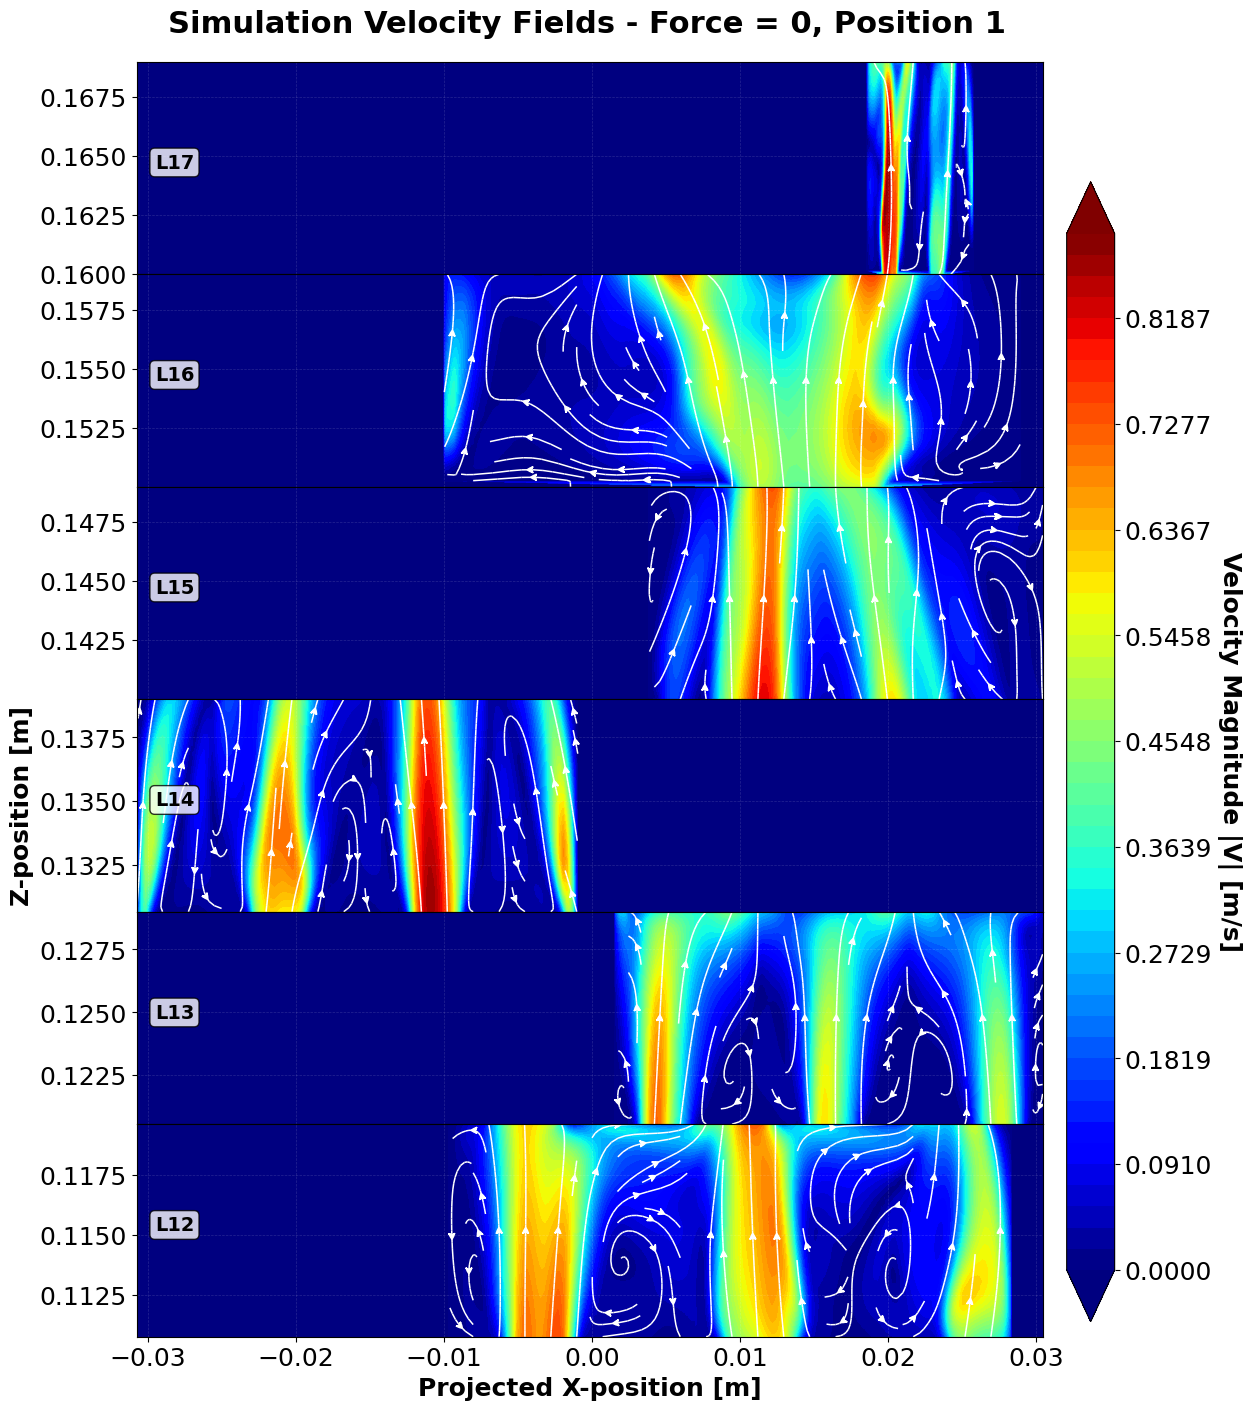

In [21]:
# Simulation visualization plot - Continuous slices without vertical gaps

n_layers = len(sim_dataframes)

fig, axes = plt.subplots(
    nrows=n_layers,
    ncols=1,
    figsize=(12, 2.5 * n_layers)
)

# Ensure axes is 1D array
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# Global X-limits for alignment
x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

for i in range(n_layers):
    df_sim = sim_dataframes[i]

    # Layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"

    ax_sim = axes[i]

    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    u_sim = df_sim[sim_u_col].values
    w_sim = df_sim[sim_w_col].values
    vel_mag_sim = df_sim['vel_magnitude'].values

    # Use GLOBAL x-range for interpolation grid (FIXED)
    xi = np.linspace(x_min_global, x_max_global, n_grid)
    zi = np.linspace(z_sim.min(), z_sim.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)

    points = np.column_stack((x_sim, z_sim))
    Ui = griddata(points, u_sim, (Xi, Zi), method='linear', fill_value=0)
    Wi = griddata(points, w_sim, (Xi, Zi), method='linear', fill_value=0)
    Vmag = griddata(points, vel_mag_sim, (Xi, Zi), method='linear', fill_value=0)

    mag = np.sqrt(Ui**2 + Wi**2)
    Ui_norm = np.zeros_like(Ui)
    Wi_norm = np.zeros_like(Wi)
    mask = mag > 1e-6
    Ui_norm[mask] = Ui[mask] / mag[mask]
    Wi_norm[mask] = Wi[mask] / mag[mask]

    contour_sim = ax_sim.contourf(
        Xi, Zi, Vmag,
        levels=levels, cmap='jet',
        vmin=common_vmin, vmax=common_vmax, extend='both'
    )
    ax_sim.streamplot(
        Xi, Zi, Ui_norm, Wi_norm,
        density=1.2, color='white',
        linewidth=1.1, arrowsize=1.0, arrowstyle='fancy'
    )

    # Set exact limits to remove extra space
    ax_sim.set_ylim(z_sim.min(), z_sim.max())
    ax_sim.set_xlim(x_min_global, x_max_global)
    ax_sim.margins(x=0, y=0)

    ax_sim.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    
    # Only bottom subplot gets x ticks/labels
    if i == n_layers - 1:
        ax_sim.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=18)
        ax_sim.set_xlabel('Projected X-position [m]', fontsize=18, fontweight='bold')
    else:
        ax_sim.tick_params(axis='x', bottom=False, labelbottom=False)
    
    ax_sim.tick_params(axis='y', left=True, labelleft=True, labelsize=18)

    # Row label
    ax_sim.annotate(
        layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
    )

# Y label on middle plot
mid_idx = n_layers // 2
axes[mid_idx].set_ylabel('Z-position [m]', fontsize=18, fontweight='bold')

# Layout - NO VERTICAL GAPS for continuous appearance
fig.subplots_adjust(
    right=0.88,
    top=0.96,
    hspace=0.0,  # No vertical space between subplots
    wspace=0.0
)

# Colorbar
cbar_ax = fig.add_axes([0.90, 0.12, 0.04, 0.76]) # (left, bottom, width, height)
cbar = fig.colorbar(contour_sim, cax=cbar_ax)
cbar.set_label(
    'Velocity Magnitude |V| [m/s]',
    rotation=270,
    labelpad=22,
    fontsize=18, fontweight='bold'
)
cbar.ax.tick_params(labelsize=18)

# Title
fig.suptitle(
    f'Simulation Velocity Fields - Force = {Force}, Position {position}',
    fontsize=22, fontweight='bold', y=0.995
)

plt.savefig(f'{output_dir}/Parallel_Sim_Velocity_Fields_Pos{position}_Force{Force}.png',
            dpi=300, bbox_inches='tight')
plt.show()


Plotting at distances from bottom (mm): [2.0, 4.0, 6.0, 8.0]
Total number of plots: 4
Global X-axis range: [-0.030750, 0.030450] m

Saved: ../Plots/Tanya_test/Sim_Line_Profiles_from_Bottom_Pos1_Force0.png


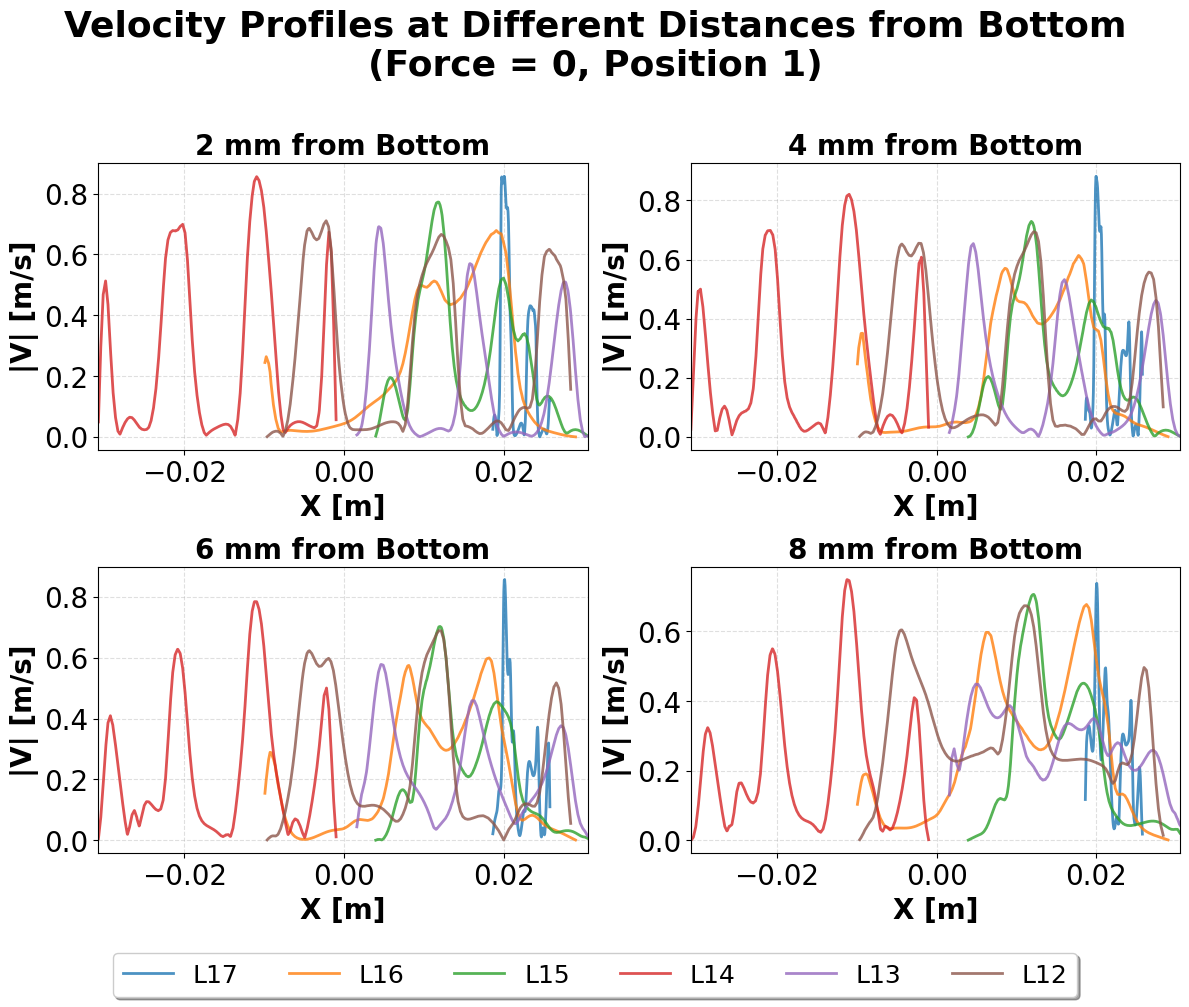

In [22]:
# Line plots at specific distances from bottom of layer
# Show all simulation layers

distances_from_bottom = np.arange(distance_step, max_distance + 1e-12, distance_step)

print(f"\nPlotting at distances from bottom (mm): {[d*1000 for d in distances_from_bottom]}")
print(f"Total number of plots: {len(distances_from_bottom)}")

# Calculate global x-limits from simulation data for consistent x-axis across subplots
x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

print(f"Global X-axis range: [{x_min_global:.6f}, {x_max_global:.6f}] m")

# Determine subplot layout
n_plots = len(distances_from_bottom)
if n_plots <= 4:
    n_rows, n_cols = 2, 2
elif n_plots <= 6:
    n_rows, n_cols = 2, 3
elif n_plots <= 9:
    n_rows, n_cols = 3, 3
else:
    n_rows, n_cols = 3, 4

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

# Process each distance from bottom
for idx, distance in enumerate(distances_from_bottom):
    deci = 5  # Precision for filtering
    ax = axes[idx]
    
    # Plot all SIMULATION layers
    for i, df_sim in enumerate(sim_dataframes):
        # Calculate z-position for this layer (distance from its bottom)
        z_min_layer = df_sim[sim_z_col].min()
        z_target = z_min_layer + distance
        
        # Check if this distance exists in this layer
        if z_target <= df_sim[sim_z_col].max():
            # Find closest z-value in simulation data
            closest_z_sim = df_sim[sim_z_col].iloc[(df_sim[sim_z_col] - z_target).abs().argsort()[:1]].iloc[0]
            
            # Filter data at this Z-height
            df_sim_filtered = df_sim[abs(df_sim[sim_z_col] - closest_z_sim) < 10**(-deci)]
            
            if len(df_sim_filtered) > 0:
                df_sim_filtered = df_sim_filtered.sort_values(sim_x_col)
                
                # Extract layer label from filename
                sim_match = re.search(r'L(\d{2})', sim_file_names[i])
                layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
                
                # Plot simulation layer
                ax.plot(df_sim_filtered[sim_x_col], df_sim_filtered['vel_magnitude'], 
                       label=layer_label, linestyle='-', linewidth=2.0, alpha=0.8)
    
    # Configure subplot with consistent x-limits
    ax.set_xlim(x_min_global, x_max_global)
    ax.set_xlabel('X [m]', fontsize=20, fontweight='bold')
    ax.set_ylabel('|V| [m/s]', fontsize=20, fontweight='bold')
    ax.set_title(f'{distance*1000:.0f} mm from Bottom', fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    ax.tick_params(axis='both', labelsize=20)

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

# Create single legend at the bottom for all subplots
handles, labels = axes[0].get_legend_handles_labels()

# Place legend below all subplots
ncol = ceil(len(labels))
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.02),
           ncol=ncol,
           fontsize=18,
           frameon=True,
           fancybox=True,
           shadow=True)

# Add overall title
fig.suptitle(f'Velocity Profiles at Different Distances from Bottom\n(Force = {Force}, Position {position})', 
            fontsize=26, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.96])

# Save plot
plot_filename = f'{output_dir}/Sim_Line_Profiles_from_Bottom_Pos{position}_Force{Force}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nSaved: {plot_filename}")

plt.show()


In [23]:
# Calculate height from bottom for each simulation layer
sim_heights_m = []
sim_max_vels = []
sim_layer_labels = []

# Create summary DataFrame showing max velocities per layer
print("SUMMARY: Maximum Velocity Magnitude Per Layer")

layer_names = []
layer_max_vel_sim = []
layer_max_u_sim = []
layer_max_w_sim = []

n_layers = len(sim_dataframes)

for i in range(n_layers):
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_name = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    layer_names.append(layer_name)
    layer_max_vel_sim.append(df_sim['vel_magnitude'].max())
    layer_max_u_sim.append(df_sim[sim_u_col].max())
    layer_max_w_sim.append(df_sim[sim_w_col].max())

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Layer': layer_names,
    'Max_|V|_[m/s]': layer_max_vel_sim,
    'Max_u_[m/s]': layer_max_u_sim,
    'Max_w_[m/s]': layer_max_w_sim
})

# Format and display
pd.options.display.float_format = '{:.6f}'.format
print("\n" + summary_df.to_string(index=False))

# Calculate statistics
avg_max_vel = summary_df['Max_|V|_[m/s]'].mean()
std_max_vel = summary_df['Max_|V|_[m/s]'].std()
overall_max = summary_df['Max_|V|_[m/s]'].max()

print(f"\nAverage Maximum Velocity [m/s]: {avg_max_vel:.6f}")
print(f"Standard Deviation [m/s]: {std_max_vel:.6f}")
print(f"Overall Maximum Velocity [m/s]: {overall_max:.6f}")
# Final summary statistics
print("OVERALL SIMULATION STATISTICS")
# Collect all velocity data
all_sim_u = []
all_sim_w = []
all_sim_mag = []

for df_sim in sim_dataframes:
    all_sim_u.extend(df_sim[sim_u_col].values)
    all_sim_w.extend(df_sim[sim_w_col].values)
    all_sim_mag.extend(df_sim['vel_magnitude'].values)

# Convert to arrays
all_sim_u = np.array(all_sim_u)
all_sim_w = np.array(all_sim_w)
all_sim_mag = np.array(all_sim_mag)

# Calculate statistics
stats_df = pd.DataFrame({
    'Component': ['u (X-velocity)', 'w (Z-velocity)', '|V| (Magnitude)'],
    'Min [m/s]': [all_sim_u.min(), all_sim_w.min(), all_sim_mag.min()],
    'Mean [m/s]': [all_sim_u.mean(), all_sim_w.mean(), all_sim_mag.mean()],
    'Max [m/s]': [all_sim_u.max(), all_sim_w.max(), all_sim_mag.max()],
    'Std Dev [m/s]': [all_sim_u.std(), all_sim_w.std(), all_sim_mag.std()]
})

pd.options.display.float_format = '{:.6f}'.format
print("\n" + stats_df.to_string(index=False))

combined_path = f'{output_dir}/simulation_summary_combined_Pos{position}_Force{Force}.png.csv'

with open(combined_path, 'w') as f:
    f.write("=== MAXIMUM VELOCITY PER LAYER ===\n")
    summary_df.to_csv(f, index=False)
    f.write("\n=== OVERALL SIMULATION STATISTICS ===\n")
    stats_df.to_csv(f, index=False)

print(f"Saved combined summary to: {combined_path}")

# Reset display format
pd.reset_option('display.float_format')

SUMMARY: Maximum Velocity Magnitude Per Layer

Layer  Max_|V|_[m/s]  Max_u_[m/s]  Max_w_[m/s]
  L17       0.891419     0.477730     0.870452
  L16       0.757038     0.358343     0.712898
  L15       0.815037     0.109082     0.811888
  L14       0.868847     0.290035     0.866761
  L13       0.715300     0.336867     0.712668
  L12       0.746552     0.328301     0.742239

Average Maximum Velocity [m/s]: 0.799032
Standard Deviation [m/s]: 0.070985
Overall Maximum Velocity [m/s]: 0.891419
OVERALL SIMULATION STATISTICS

      Component  Min [m/s]  Mean [m/s]  Max [m/s]  Std Dev [m/s]
 u (X-velocity)  -0.518294    0.005625   0.477730       0.080247
 w (Z-velocity)  -0.134333    0.210846   0.870452       0.223895
|V| (Magnitude)   0.000029    0.232746   0.891419       0.216530
Saved combined summary to: ../Plots/Tanya_test/simulation_summary_combined_Pos1_Force0.png.csv


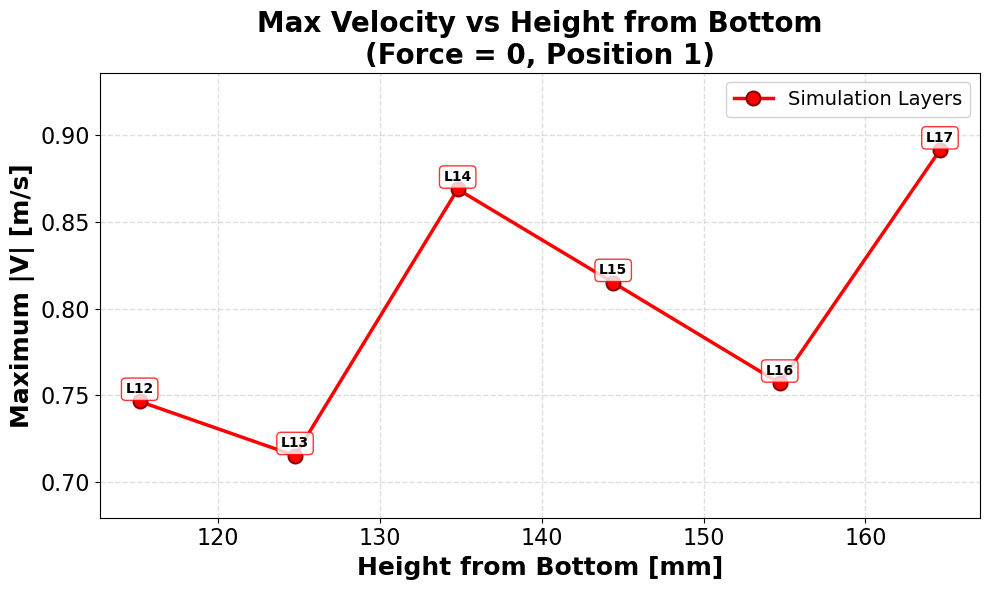

In [24]:
# Maximum velocity vs height from bottom
sim_heights_m = []
sim_max_vels = []
sim_layer_labels = []
for i, df_sim in enumerate(sim_dataframes):
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    # Calculate average height (Z) for the layer
    avg_height = df_sim[sim_z_col].mean()
    sim_heights_m.append(avg_height)
    
    # Maximum velocity magnitude for the layer
    max_vel = df_sim['vel_magnitude'].max()
    sim_max_vels.append(max_vel)
    
    sim_layer_labels.append(layer_label)

sim_heights_mm = np.array(sim_heights_m) * 1000

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sim_heights_mm, sim_max_vels, 'ro-', label='Simulation Layers',
        linewidth=2.5, markersize=10, markeredgecolor='darkred', markeredgewidth=1.5)

# Add layer labels
for i, (height, vel, label) in enumerate(zip(sim_heights_mm, sim_max_vels, sim_layer_labels)):
    ax.annotate(label, xy=(height, vel), xytext=(height, vel+0.003),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='red', alpha=0.8),
                ha='center', va='bottom')
ax.set_ylim(min(sim_max_vels)*0.95, max(sim_max_vels)*1.05)
ax.set_xlabel('Height from Bottom [mm]', fontsize=18, fontweight='bold')
ax.set_ylabel('Maximum |V| [m/s]', fontsize=18, fontweight='bold')
ax.set_title(f'Max Velocity vs Height from Bottom\n(Force = {Force}, Position {position})',
             fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=14, loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{output_dir}/Max_Velocity_vs_Height_Pos{position}_Force{Force}.png', dpi=300, bbox_inches='tight')
plt.show()

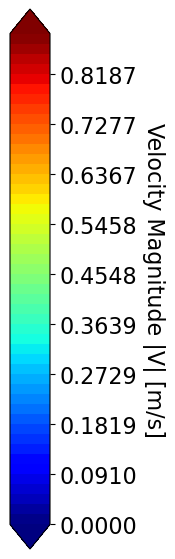

In [25]:
# Plot only vertical colorbar (uses existing `contour_sim`, `common_vmin`, `common_vmax`, `output_dir`, `position`, `Force`)
fig = plt.figure(figsize=(2, 6))
cax = fig.add_axes([0.18, 0.05, 0.2, 0.9]) #(left, bottom, width, height)
cbar = fig.colorbar(contour_sim, cax=cax, orientation='vertical')
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=20, fontsize=16)
cbar.ax.tick_params(labelsize=16)
plt.savefig(f'{output_dir}/Colorbar_vertical_Pos{position}_Force{Force}.png', dpi=300, bbox_inches='tight')
plt.show()